# College Scorecard Provisional Analysis (DOE) 

Hypothesis 1 (College Scorecard): Students who attend more racially and demographically diverse universities will demonstrate higher median earnings after graduation, reflecting the broad economic and social benefits of diverse educational environments.

- Expect that more homogenous universities (excl. HBCU's) will have worse outcomes for students
- Control for: family income distribution, completion rates


In [1]:
#setup chunk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from IPython.display import IFrame

In [2]:
#data cleaning process-- especially making smaller datasets that are more manageable and only include relevant variables

dat = pd.read_csv('../data/Glynn_data/combined_data.csv')
dat.columns

Index(['univ_id', 'univ_name', 'state', 'zip_code', 'percent_pell',
       'completion_rate_fry', 'ugds_white', 'ugds_black', 'ugds_hisp',
       'ugds_asian', 'ugds_aian', 'ugds_nhpi', 'ugds_2mor', 'ugds_nra',
       'ugds_unkn', 'ugds_men', 'ugds_women', 'md_earn_wne_4yr', 'year',
       'hbcu', 'pbi', 'aanapii', 'hsi', 'tribal', 'long', 'all_male',
       'all_female', 'admit_rate', 'lat', 'pct_w_ba_hometown', 'degree_type'],
      dtype='str')

## Variable Descriptions: 
The dataset includes a few different variables which relate to the general diversity of the institution, especially the rates of different racial/ ethnic groups in the university. In addition to the composition of the university based on these groups, there is also information on whether a university is a Historically Black College or University (hbcu), or a predominantly black institution (40%+ of student body is Black). Similar tags are provided for other groups, for example, Hispanic Serving Institutions (HSIs) are defined by The Higher Education Act as not-for-profit colleges and universities where at least 25% of the full-time equivalent undergraduate enrollment is Hispanic. A few control variables are alsoc included. For example the *percent_pell* varibale refers to the percent of the school receiving pell grants, while *admit_rate* refers to the admission rate of a universtiy, with higher admit rates indicatingthat a school is less exclusive, generally. Furthermore, we have each university name, its state and zip code, and its completion rate. Most importantly for the analysis, there is also a varible which tracks the and the median earnings of students four years after graduation. 


- ugds_: different racial/ demographic variables of the student body at a university. Intuitively coded as ugds_suffix, where the suffix is the group (white, black, hispanic, asian, amarican indian and alaska native, native hawaiian and pacific islander, two or more races, norace, unknown, white nonhispanic, blacknonhispanic, asian pacific islander)
- md_earn_wne_4yr: Median earnings are calculated for individuals that were federally aided, were working, and were not enrolled in school as of the measurement point. Earnings were measured based on wages and deferred compensation reported via IRS form W-2 plus positive self-employment earnings reported via Schedule SE. Individuals with $1 or more of earnings were considered to be working and were included in the median earnings calculation.
- pct_w_ba_hometown: Percent of the population from students' zip codes with a bachelor's degree over the age 25, via Census data
- degree_type: Predominant undergraduate degree awarded: 0 Not classified, 1 Predominantly certificate-degree granting, 2 Predominantly associate's-degree granting, 3 Predominantly bachelor's-degree granting,  4 Entirely graduate-degree granting"
- completion_rate_fry: Completion rate for four year institutions 


In [3]:
#other dataset features
#dat.info()
dat['degree_type'].unique()

array([3, 1, 2, 4, 0])

There are 6,159 total universities in the dataset, but when accounting for the number of universities that are outside of the uppermost-50 (excluding Guam and Puerto Rico which do not have full statehood), the numbers change slightly...

In [4]:
#then narrow only to universities in upper-50 US (no PR or Guam)
dat['state'].value_counts()
non_50 = ['VI', 'AS', 'MP', 'FM', 'PW', 'MH', 'GU', 'PR']
    #virgin islands, american samoa, northern marina islands, federated state of micronesia, palao, guam, puerto rico

dat[~dat['state'].isin(non_50)].nunique() #taking out states not in the 50 states gives us 51 unique states (since the dataset includes DC)
#filtering
dat = dat[~dat['state'].isin(non_50)]

After filtering only to the 'upper-50' states, including Washington DC, there are 6,009 unique universities, 150 less than in the original dataset.

In [5]:
#narrow to predominantly undergraduate-degree granting universities
dat['degree_type'].value_counts() 
#there are about 1898 unique observations of this type

degree_type
1    2499
3    1898
2     949
0     398
4     265
Name: count, dtype: int64

In [6]:
dat[dat['degree_type']==3].nunique()
#dat[dat['univ_name'].duplicated()] #this line of code demonstrates that 
    #the higher number of university IDs relative to the number of university names is due to repeated names (e.g. Bethel University)


univ_id                1898
univ_name              1886
state                    51
zip_code               1832
percent_pell           1577
completion_rate_fry    1407
ugds_white             1600
ugds_black             1291
ugds_hisp              1349
ugds_asian              877
ugds_aian               261
ugds_nhpi               166
ugds_2mor               710
ugds_nra                821
ugds_unkn               766
ugds_men               1452
ugds_women             1452
md_earn_wne_4yr        1584
year                      1
hbcu                      2
pbi                       2
aanapii                   2
hsi                       2
tribal                    2
long                   1879
all_male                  2
all_female                2
admit_rate             1335
lat                    1880
pct_w_ba_hometown       959
degree_type               1
dtype: int64

In [7]:
#keep only 4-yr institutions
dat = dat[dat['degree_type']==3]

After filtering non-undergraduate universities, there are 1,942 universities in the dataset. 


Since I expect that students who attend more racially and demographically diverse universities will demonstrate higher median earnings after graduation, we might expect to see some visual connection between the racial composition of a unviersity and our key outcome variable.


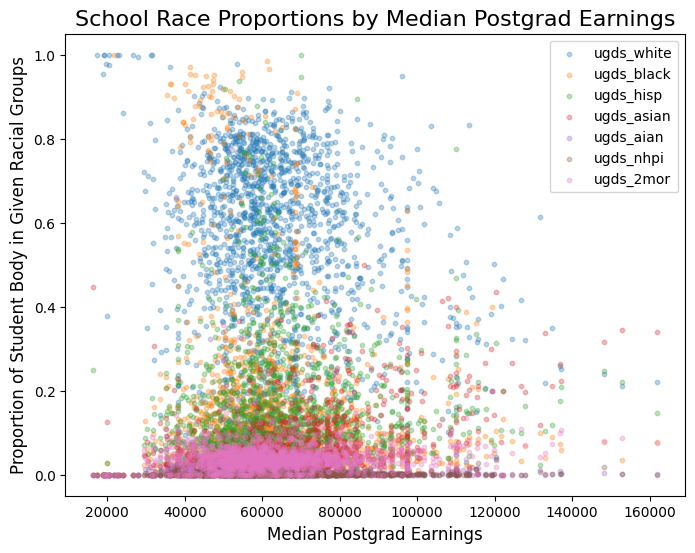

In [10]:
race_cols = ['ugds_white', 'ugds_black', 'ugds_hisp', 'ugds_asian', 'ugds_aian', 
             'ugds_nhpi', 'ugds_2mor']

#convert the IV to numeric: 
dat['md_earn_wne_4yr'] = pd.to_numeric(dat['md_earn_wne_4yr'], errors='coerce')


fig, ax = plt.subplots(figsize = (8,6))

for col in race_cols: 
    ax.scatter(dat['md_earn_wne_4yr'], dat[col], label=col, alpha=0.3, s=10)

ax.set_title("School Race Proportions by Median Postgrad Earnings", fontsize = 16)
ax.set_xlabel('Median Postgrad Earnings', fontsize=12)
ax.set_ylabel('Proportion of Student Body in Given Racial Groups', fontsize=12)
plt.legend()

plt.show()

In this graph, each point represents the composition of a different racial group for a given university. 

If we did see an effect of *individual* racial groups on postgrad earnings, we would expect a classic linear relationship, where as the proportion of a racial group increases, so do the median postgrad earnings. This is somewhat visible at the tail of the Asian American group (pink), where after the earning threshold of 80,000, the earnings seem to increase sas the percent of Asian Americans does at a school. 
There is a similar, albeit less strong relationship at the right end of the right side of White postgrad earnings, but there are also significant outliers skewed toward the bottom right and upper left of the graph. 

From this graph, it's impossible to tell whether as the proportion of a racial group close to 80% or higher increases, the colleges' expected median earnings do too. The relative lack of data in the top right corner seems to somewhat support this hypothesis, with the highest-earning schools seeming to have a somewhat equally distributed mix of races between 0-0.4% of their student body.  

The first graph demonstrates a few patterns/ outliers to explore and correct here: 
1. There are quite a few dots clustered at the top of the distribution at exactly 1, indicating completely white and one completely Black university. The Black outlier might represent an HBCU, while the White and singular Hispanic outliers warrant further explanation.  
2. The outliers at the right end of the earnings axis seem to resemble one another. Check what universities these are, and what their racial composition is. My guess is that highly selective universities can tailor their student body to be some combination of representative and diverse in a way that less seelctive universities (who probably have worse earning outcomes) cannot.  


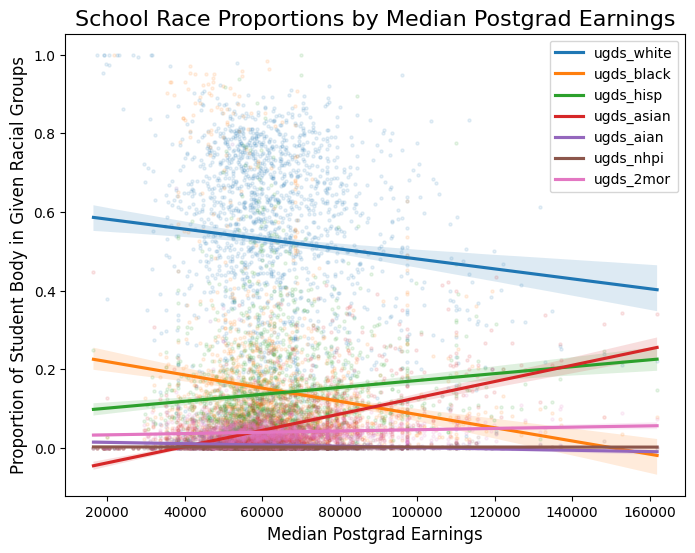

In [11]:
#changing to a regression plot to see clearer trends between racial groups

fig, ax = plt.subplots(figsize = (8,6))

for col in race_cols: 
    sns.regplot(data = dat, x = 'md_earn_wne_4yr', y = col,  
                scatter_kws = {'alpha': 0.1, 's':5}, 
                line_kws = {'label': col}, 
                ax = ax)

ax.set_title("School Race Proportions by Median Postgrad Earnings", fontsize = 16)
ax.set_xlabel('Median Postgrad Earnings', fontsize=12)
ax.set_ylabel('Proportion of Student Body in Given Racial Groups', fontsize=12)
plt.legend()

plt.show()

The regression lines added to the plot demonstrate the average trend in earnings increases according to the proportion of a student body in a given racial group. 

Schools with high populations of Asian students tend to report better median earnings for their students later on. We might explain this through racial biases in the labor market, and the socioeconomically advantaged position of White and Asian Americans for the most part, who are overrepresetned in the [middle and upper classes](https://www.pewresearch.org/race-and-ethnicity/2024/05/31/the-state-of-the-asian-american-middle-class/), with respect to their proportions in the populaition. Schools with higher populations of Hispanic students also seem to have higher average median earnings, although to a lesser extent than is the case with Asian Americans. 

Conversely, among schools who have increased shares of Black and White students, median earnings tend to go down. In particular, it seems that schools with disproportionately white student bodies (above 70 percent) are clustered at the lower end of the earnings spectrum, while schools with significantly higher earnings have White student populations around 40%. The similar trend for Black students might be attributed, instead to the relatively low proportion of Black students represented in the universities at the higher end of the postgrad earnings spectrum.  


### Next steps: 
- Create diversity index
- Create representativeness index
- Regression (incl. controls for pell grants and completion rates)

In [21]:
#make a designated label for hbcus and other special racially designated universities on the graph 
#identify hbcus, etc. 
n_hsi = len(dat[dat['hsi']>=0.98]) #249 Hispanic serving institutions
n_hbcu = len(dat[dat['hbcu']>=0.98]) #83 hbcus
n_tribal = len(dat[dat['tribal']>=0.98]) #2 tribal universities
n_pbi = len(dat[dat['pbi']>=0.98]) #19 primarily black institutions

#make an output table of these values 

In [22]:
#the goal is to make a faceted graph for each of the racial groups
    #each graph willl have a horizontal line for the proportion of that group in the population
    #then there will be specially shaped dots to represent universities specifically designated by the DOE as hbcus, hsis, etc. 
    #have a label for the regression line 

In [ ]:
##Investigate universities who are outliers in percent of student body == 1

In [ ]:
#revise this code: plt.text(x[1], y[1] + 1, "Target Point", ha='center') 
fig, ax = plt.subplots(figsize = (8,6))

for col in race_cols: 
    sns.regplot(data = dat, x = 'md_earn_wne_4yr', y = col,  
                scatter_kws = {'alpha': 0.1, 's':5}, 
                line_kws = {'label': col}, 
                ax = ax)

ax.set_title("School Race Proportions by Median Postgrad Earnings", fontsize = 16)
ax.set_xlabel('Median Postgrad Earnings', fontsize=12)
ax.set_ylabel('Proportion of Student Body in Given Racial Groups', fontsize=12)
plt.legend()

plt.show()

In [ ]:
#Investigate the outliers at the upper end of the earnings

In [18]:
#Expect that more homogenous universities (excl. HBCU’s) will have worse outcomes for students
dat[dat['md_earn_wne_4yr']>=120000].head()

,univ_id,univ_name,state,zip_code,percent_pell,completion_rate_fry,ugds_white,ugds_black,ugds_hisp,ugds_asian,...,aanapii,hsi,tribal,long,all_male,all_female,admit_rate,lat,pct_w_ba_hometown,degree_type
187,110404,California Institute of Technology,CA,91125,0.1398,0.9404,0.2118,0.0346,0.2200,0.3442,...,0.0,0.0,0.0,-118.125878,0.0,0.0,0.0257,34.137349,23.4400005340576,3
294,115409,Harvey Mudd College,CA,91711,0.1293,0.9202,0.2528,0.0596,0.2097,0.2241,...,0.0,0.0,0.0,-117.709837,0.0,0.0,0.1266,34.106515,23.5900001525878,3
399,122296,Samuel Merritt University,CA,94609,0.1827,NaN,0.2389,0.0786,0.2478,0.3160,...,0.0,0.0,0.0,-122.266331,0.0,0.0,NaN,37.820290,23.0699996948242,3
820,144050,University of Chicago,IL,60637,0.1294,0.9558,0.3215,0.0674,0.1631,0.1978,...,0.0,0.0,0.0,-87.599539,0.0,0.0,0.0448,41.787994,21.8099994659423,3
1380,166027,Harvard University,MA,02138,0.1341,0.9777,0.3491,0.0896,0.1174,0.2121,...,0.0,0.0,0.0,-71.118313,0.0,0.0,0.0365,42.374471,22.8099994659423,3


Investigating the first few rows of data from the higher ends of the earnings spectrum, the idea that more exclusive universities are on the far end of the spectrum is supported. Highly selective universities (UChicago and Harvard, for example), are joined by universities that deliver medical degrees. 

In [ ]:
#Control for: family income distribution, completion rates, and the general exclusivity (admit rate)